# DeepLense: Model Training and Evaluation Demo
This notebook demonstrates the end-to-end training pipeline for the DeepLense project. 
Instead of running the CLI module (`uv run -m scripts.train`), we programmatically load the Hydra configuration, instantiate the `Trainer`, run a short demonstration training loop, and extract the resulting metrics and artifacts directly from MLflow.

I will begin with the results of the best training run and then show a demo of how the pipeline works

In [2]:
import os
import sys
from pathlib import Path

print(f"Original CWD: {os.getcwd()}")

os.chdir("../..")
sys.path.append(os.getcwd())
    
print(f"New CWD: {os.getcwd()}")

Original CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion\notebooks\Common Task 1
New CWD: d:\Shreyas\ML4Sci-Deeplense-Diffusion


In [3]:
import os
import torch
import mlflow
import matplotlib.pyplot as plt
from hydra import initialize, compose
from IPython.display import Image, display

import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

d:\Shreyas\ML4Sci-Deeplense-Diffusion\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch Version: 2.10.0+cu126
CUDA Available: True


In [9]:
import tempfile
from IPython.display import Markdown

BEST_RUN_ID = "87dac1155c2c4e00a65ba0abd2bb6120"

# CONFIGURATION
CONFIG_ARTIFACT_PATH = "config/config.yaml"

client = mlflow.tracking.MlflowClient()

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        # Download the config file directly from MLflow's artifact store
        local_config_path = client.download_artifacts(
            BEST_RUN_ID, CONFIG_ARTIFACT_PATH, tmp_dir
        )

        # Read the YAML text
        with open(local_config_path, "r") as f:
            config_text = f.read()

        # Render it beautifully in Jupyter with syntax highlighting
        display(
            Markdown(
                f"### Experiment Configuration (Run ID: `{BEST_RUN_ID}`)\n"
                f"```yaml\n{config_text}\n```"
            )
        )

    except Exception as e:
        print(f"Could not load the configuration artifact. Error: {e}")

### Experiment Configuration (Run ID: `87dac1155c2c4e00a65ba0abd2bb6120`)
```yaml
dataset:
  name: deeplense_classify
  image_size: 150
  batch_size: 64
  data_root: datasets/deeplense_classify/dataset
model:
  metrics:
    acc:
      name: accuracy
    roc_auc:
      name: roc_auc
    roc:
      name: roc
  name: efficient_net_b2
  type: classifier
  backbone:
    pretrained: true
    num_classes: 3
    in_channels: 1
training:
  epochs: 10
  lr: 0.0002
  ema_decay: 0.9999
sampling:
  num_images: 16
  sample_every_n_epochs: 2
device: cuda
experiment_name: efficient_net_b2_deeplense_classify_initial_test
seed: 42
resume_from_run_id: null

```

Fetching Final Results from MLflow Run: 87dac1155c2c4e00a65ba0abd2bb6120

Final Validation ROC AUC: 0.9041
Final Validation Accuracy: 0.7451



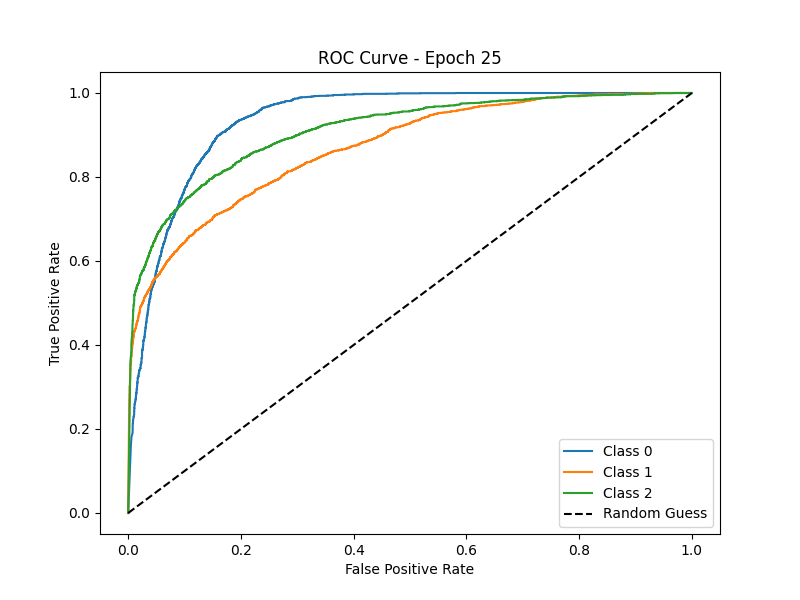

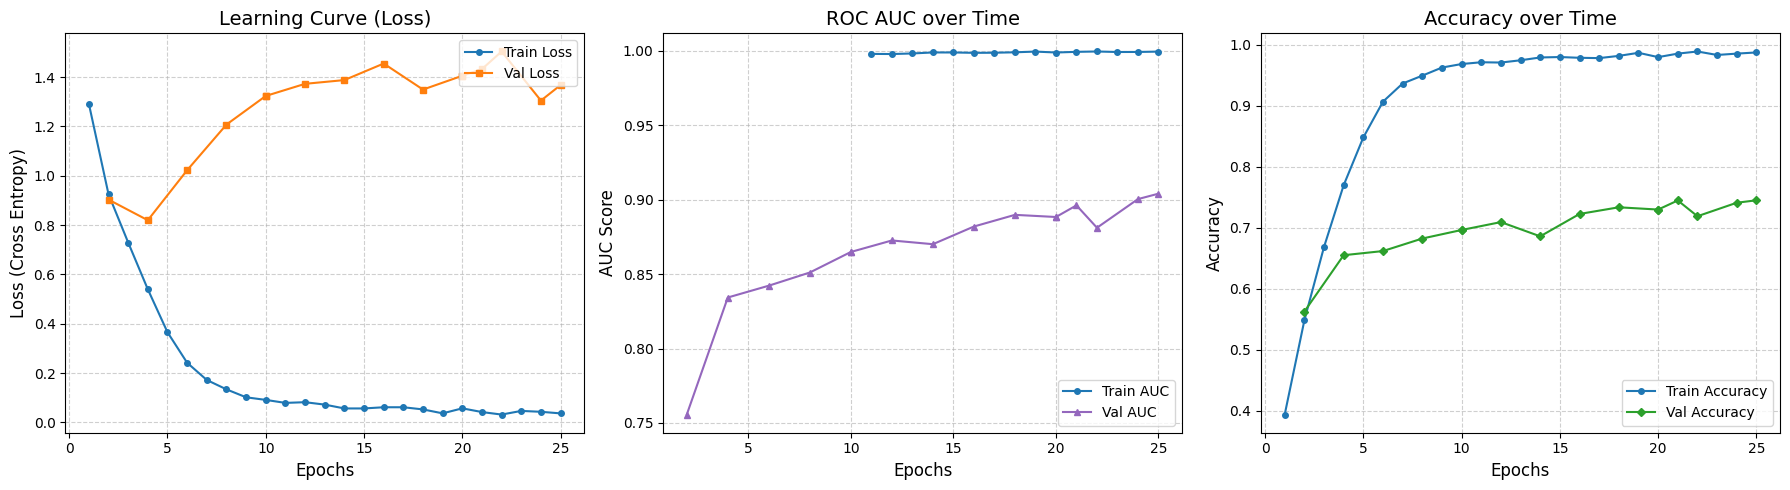

In [10]:
print(f"Fetching Final Results from MLflow Run: {BEST_RUN_ID}\n")

def fetch_metric(metric_name):
    try:
        history = client.get_metric_history(BEST_RUN_ID, metric_name)
        return [m.step for m in history], [m.value for m in history]
    except Exception:
        return [], []

# Fetch metrics
epochs_tl, train_loss = fetch_metric("avg_loss")
epochs_vl, val_loss = fetch_metric("val_avg_loss")

epochs_ta, train_auc = fetch_metric("roc_auc")
epochs_va, val_auc = fetch_metric("val_roc_auc")

epochs_tacc, train_acc = fetch_metric("accuracy")
epochs_vacc, val_acc = fetch_metric("val_accuracy")

final_auc = val_auc[-1] if val_auc else "N/A"
final_acc = val_acc[-1] if val_acc else "N/A"

print(f"Final Validation ROC AUC: {final_auc:.4f}")
if final_acc != "N/A":
    print(f"Final Validation Accuracy: {final_acc:.4f}\n")

with tempfile.TemporaryDirectory() as tmp_dir:
    try:
        artifact_path = "validation_metrics/roc_curve_epoch_25.png" 
        local_path = client.download_artifacts(BEST_RUN_ID, artifact_path, tmp_dir)
        display(Image(filename=local_path))
    except Exception as e:
        print(f"Could not load the final ROC curve artifact: {e}")

# Plotting
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Loss
if train_loss and val_loss:
    axes[0].plot(epochs_tl, train_loss, label="Train Loss", color="tab:blue", marker="o", markersize=4)
    axes[0].plot(epochs_vl, val_loss, label="Val Loss", color="tab:orange", marker="s", markersize=4)
    axes[0].set_title("Learning Curve (Loss)", fontsize=14)
    axes[0].set_xlabel("Epochs", fontsize=12)
    axes[0].set_ylabel("Loss (Cross Entropy)", fontsize=12)
    axes[0].legend(loc="upper right")
    axes[0].grid(True, linestyle="--", alpha=0.6)

# Plot 2: ROC AUC
if train_auc and val_auc:
    axes[1].plot(epochs_ta, train_auc, label="Train AUC", color="tab:blue", marker="o", markersize=4)
    axes[1].plot(epochs_va, val_auc, label="Val AUC", color="tab:purple", marker="^", markersize=5)
    axes[1].set_title("ROC AUC over Time", fontsize=14)
    axes[1].set_xlabel("Epochs", fontsize=12)
    axes[1].set_ylabel("AUC Score", fontsize=12)
    axes[1].legend(loc="lower right")
    axes[1].grid(True, linestyle="--", alpha=0.6)

# Plot 3: Accuracy
if train_acc and val_acc:
    axes[2].plot(epochs_tacc, train_acc, label="Train Accuracy", color="tab:blue", marker="o", markersize=4)
    axes[2].plot(epochs_vacc, val_acc, label="Val Accuracy", color="tab:green", marker="D", markersize=4)
    axes[2].set_title("Accuracy over Time", fontsize=14)
    axes[2].set_xlabel("Epochs", fontsize=12)
    axes[2].set_ylabel("Accuracy", fontsize=12)
    axes[2].legend(loc="lower right")
    axes[2].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [5]:
# Initialize Hydra and load the config
with initialize(version_base=None, config_path=f"../../configs"):
    # We can override config values right here, just like in the terminal
    # We set epochs to 2 for a quick demonstration.
    cfg = compose(config_name="config", overrides=["training.epochs=2", "sampling.sample_every_n_epochs=1"])

print("Active Configuration Configuration:")
print(f"Model: {cfg.model.name} ({cfg.model.type})")
print(f"Dataset: {cfg.dataset.name}")
print(f"Epochs: {cfg.training.epochs}")

Active Configuration Configuration:
Model: pinn_efficient_net_b2 (classifier)
Dataset: deeplense_classify
Epochs: 2


In [6]:
from src.data import get_dataloaders, get_datasets, get_stats as get_stats_fn
from src.data.config import DataConfig
from src.models import get_model
from src.training.trainer import Trainer
from src.metrics import get_metric

# Load Data
data_config = DataConfig(**cfg.dataset)
train_dataset, test_dataset = get_datasets(data_config)
train_loader, test_loader = get_dataloaders(data_config)
get_stats = get_stats_fn(data_config)

# Load Model
model = get_model(cfg)

# Load Metrics
metrics = {}
for metric_cfg in cfg.model.metrics.values():
    metrics[metric_cfg.name] = get_metric(metric_cfg, cfg)

# Setup Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.training.lr)

# Initialize Trainer
trainer = Trainer(
    model=model,
    train_dataloader=train_loader,
    test_dataloader=test_loader,
    test_dataset=test_dataset,
    optimizer=optimizer,
    get_stats=get_stats,
    config=cfg,
    start_epoch=1,
    metrics=metrics
)

Loading dataset: deeplense_classify
Loading dataset: deeplense_classify
Trainer initialized for mode: CLASSIFIER
EMA enabled with decay rate: 0.9999


Fetching a fixed sample batch from the dataloader...


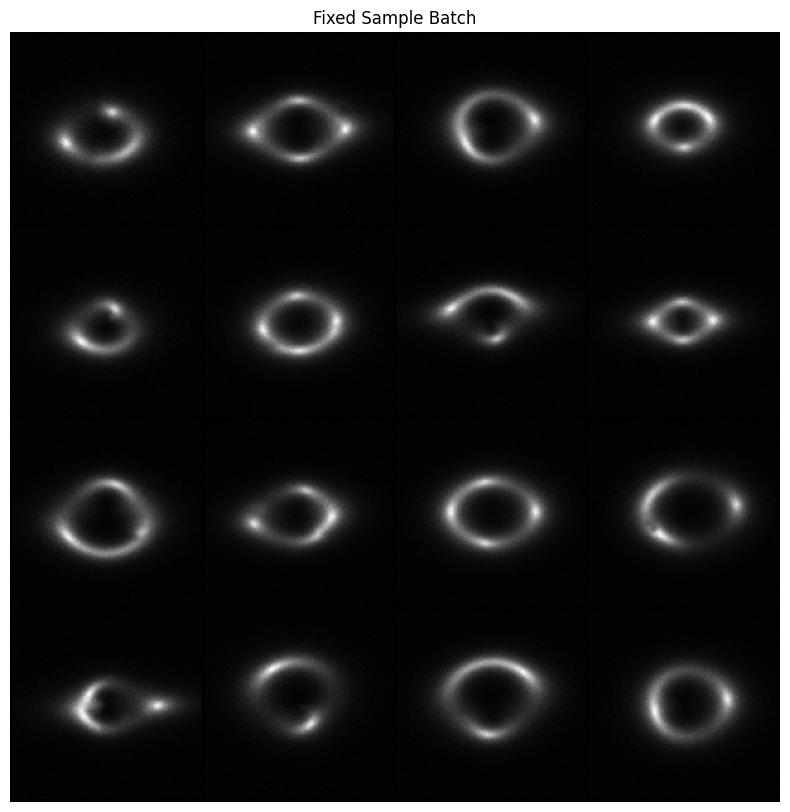

In [7]:
# Visualize what the model is about to see
print("Fetching a fixed sample batch from the dataloader...")
trainer.plot_fixed_batch()

In [8]:
# Start the MLflow run
mlflow.set_experiment(cfg.experiment_name)

with mlflow.start_run() as run:
    run_id = run.info.run_id
    print(f"Started MLflow Run ID: {run_id}")
    
    # Run short 2-epoch demo
    trainer.train()
    
print("Demonstration training complete!")

Started MLflow Run ID: 0d7ad8cf1b3541a98fe0c26da6667e59
Starting training from epoch 1...


Epoch 1:  17%|█▋        | 80/469 [00:27<02:15,  2.87it/s, loss=1.53]


KeyboardInterrupt: 

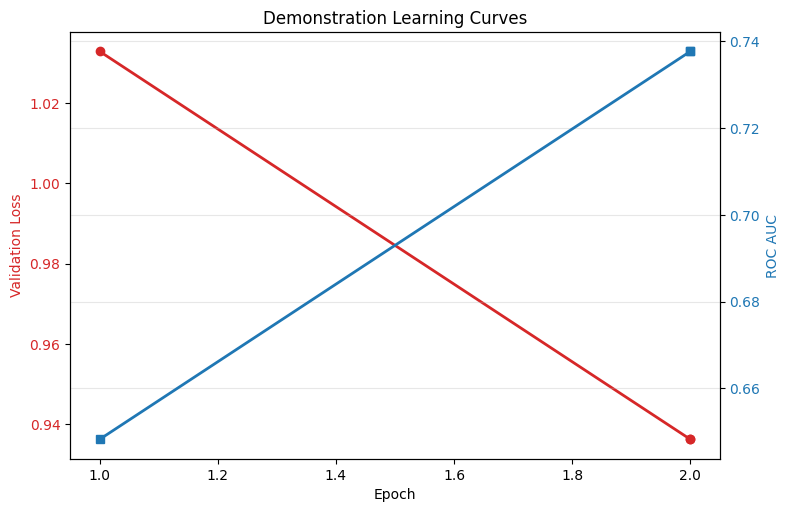

In [ ]:
# Fetch the metric history for the run we just completed
client = mlflow.tracking.MlflowClient()

# Extract Validation Loss and ROC AUC
try:
    loss_history = client.get_metric_history(run_id, "val_avg_loss")
    auc_history = client.get_metric_history(run_id, "val_roc_auc")
    
    epochs = [m.step for m in loss_history]
    losses = [m.value for m in loss_history]
    aucs = [m.value for m in auc_history]

    # Plot the learning curves
    fig, ax1 = plt.subplots(figsize=(8, 5))

    color = 'tab:red'
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Validation Loss', color=color)
    ax1.plot(epochs, losses, color=color, marker='o', linewidth=2)
    ax1.tick_params(axis='y', labelcolor=color)

    ax2 = ax1.twinx()  
    color = 'tab:blue'
    ax2.set_ylabel('ROC AUC', color=color)  
    ax2.plot(epochs, aucs, color=color, marker='s', linewidth=2)
    ax2.tick_params(axis='y', labelcolor=color)

    fig.tight_layout()  
    plt.title("Demonstration Learning Curves")
    plt.grid(True, alpha=0.3)
    plt.show()
except Exception as e:
    print(f"Could not fetch metric history: {e}")

Latest ROC Curve from MLflow Artifacts:


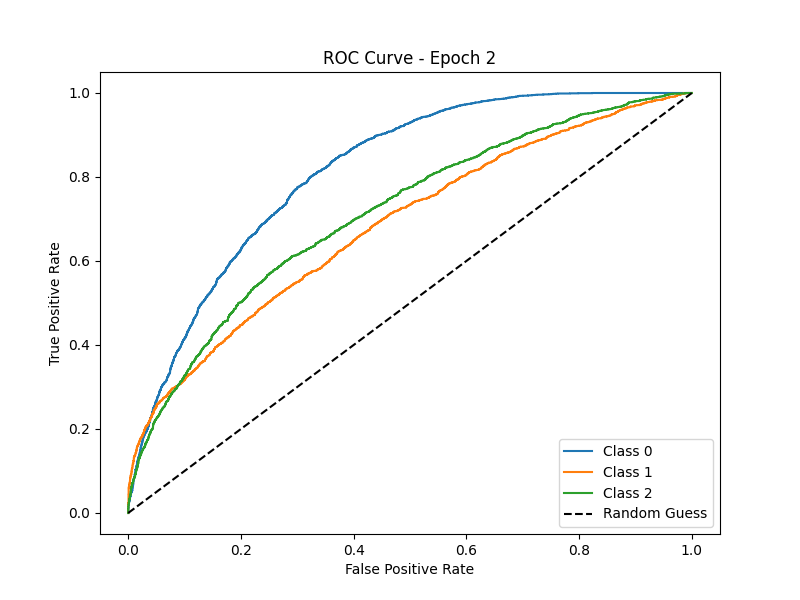

In [ ]:
# Download the ROC curve image generated by the trainer and display it directly
import tempfile

with tempfile.TemporaryDirectory() as tmp_dir:
    # Download the specific artifact
    artifact_path = "validation_metrics/roc_curve_epoch_2.png"
    local_path = client.download_artifacts(run_id, artifact_path, tmp_dir)
    
    print("Latest ROC Curve from MLflow Artifacts:")
    display(Image(filename=local_path))